In [1]:
!sudo apt install tesseract-ocr
!pip install pytesseract pillow


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


In [2]:
from PIL import Image
import pytesseract
import requests
from io import BytesIO


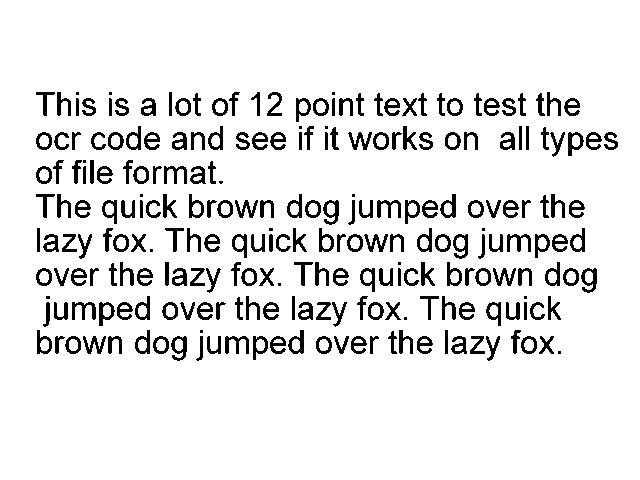

In [5]:
from google.colab import files
uploaded = files.upload()




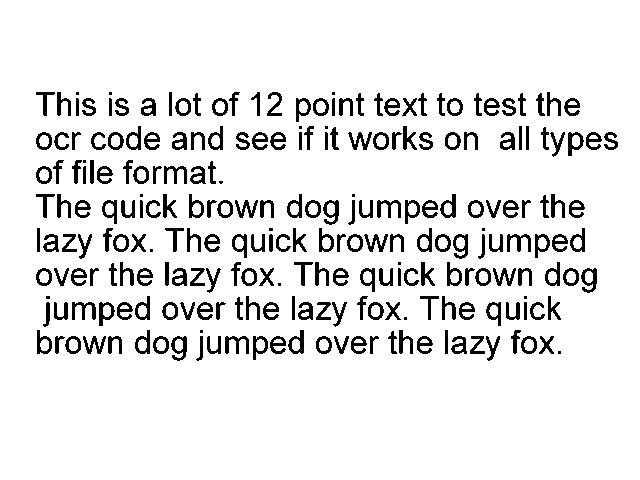

In [6]:
# Replace 'your_image.png' with your uploaded file name
image = Image.open("/content/testocr (1).png")
image

In [7]:
# Perform OCR
text = pytesseract.image_to_string(image)

print("📜 Extracted Text:")
print(text)


📜 Extracted Text:
This is a lot of 12 point text to test the
ocr code and see if it works on all types
of file format.

The quick brown dog jumped over the
lazy fox. The quick brown dog jumped
over the lazy fox. The quick brown dog
jumped over the lazy fox. The quick
brown dog jumped over the lazy fox.



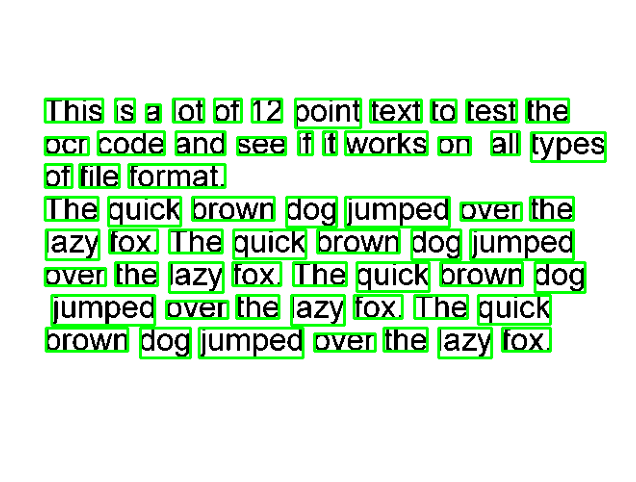

In [8]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Convert PIL image to OpenCV format
cv_image = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

# Get word-level data
data = pytesseract.image_to_data(image, output_type=pytesseract.Output.DICT)

# Draw boxes around detected text
for i in range(len(data['text'])):
    if int(data['conf'][i]) > 60:  # Confidence threshold
        x, y, w, h = data['left'][i], data['top'][i], data['width'][i], data['height'][i]
        cv2.rectangle(cv_image, (x, y), (x + w, y + h), (0, 255, 0), 2)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(cv_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()
